In [1]:
# Import libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import statistics

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

import sklearn 
import sklearn.datasets
import sklearn.cross_decomposition
import sklearn.decomposition
import sklearn.neighbors
import sklearn.metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler

import ipympl

%matplotlib widget

file_path = 'Cinemark_data_for_all_algorithms.csv'

df = pd.read_csv(file_path)
df.set_index('Date_Time', inplace=True)
df = df.drop('Unnamed: 0', axis = 1)
display(df)

,Facility_Demand_Rate_kW,Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep),AUD01_Zone_Mean_Air_Temperature,AUD01_HTG_SETPT,AUD01_CLG_SETPT,AUD02_Zone_Mean_Air_Temperature,AUD02_HTG_SETPT,AUD02_CLG_SETPT,AUD03_Zone_Mean_Air_Temperature,AUD03_HTG_SETPT,...,PROJC_CLG_SETPT,PROJD_Zone_Mean_Air_Temperature,PROJD_HTG_SETPT,PROJD_CLG_SETPT,OFFICE_Zone_Mean_Air_Temperature,OFFICE_HTG_SETPT,OFFICE_CLG_SETPT,EMPLOYEE_Zone_Mean_Air_Temperature,EMPLOYEE_HTG_SETPT,EMPLOYEE_CLG_SETPT
Date_Time,,,,,,,,,,,,,,,,,,,,,
01/01 00:05:00,190.426026,6.7,20.475174,20.0,23.8889,20.480841,20.0,23.8889,20.243276,20.0,...,23.8889,20.001310,20.0,23.8889,20.338029,20.0,23.8889,20.001048,20.0,23.8889
01/01 00:10:00,190.360637,6.7,20.033642,20.0,23.8889,20.047459,20.0,23.8889,20.424724,20.0,...,23.8889,19.999363,20.0,23.8889,20.306129,20.0,23.8889,20.000008,20.0,23.8889
01/01 00:15:00,190.331229,6.7,20.489567,20.0,23.8889,20.478936,20.0,23.8889,20.003879,20.0,...,23.8889,20.489683,20.0,23.8889,20.275221,20.0,23.8889,20.479038,20.0,23.8889
01/01 00:20:00,190.456673,6.7,20.056314,20.0,23.8889,20.043813,20.0,23.8889,20.520028,20.0,...,23.8889,20.093437,20.0,23.8889,20.244951,20.0,23.8889,20.057682,20.0,23.8889
01/01 00:25:00,190.297697,6.7,20.473177,20.0,23.8889,20.477356,20.0,23.8889,20.153758,20.0,...,23.8889,20.001184,20.0,23.8889,20.215148,20.0,23.8889,20.488301,20.0,23.8889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12/31 23:40:00,190.877238,3.3,20.252889,20.0,23.8889,20.489481,20.0,23.8889,20.243799,20.0,...,23.8889,20.272905,20.0,23.8889,20.243910,20.0,23.8889,20.404130,20.0,23.8889
12/31 23:45:00,191.321030,3.3,20.244394,20.0,23.8889,20.006850,20.0,23.8889,20.244366,20.0,...,23.8889,20.244057,20.0,23.8889,20.508249,20.0,23.8889,20.006278,20.0,23.8889
12/31 23:50:00,190.905346,3.3,20.252896,20.0,23.8889,20.489467,20.0,23.8889,20.238186,20.0,...,23.8889,20.271679,20.0,23.8889,20.064467,20.0,23.8889,20.401844,20.0,23.8889


In [2]:
X3 = df.drop('Facility_Demand_Rate_kW',axis = 1) 
y3 = df.Facility_Demand_Rate_kW

scaler = StandardScaler()
X3_scaled = scaler.fit_transform(X3)

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)
# display(y3_test)

#kNN regression
from sklearn.neighbors import KNeighborsRegressor
# Create KNN classifier
knn = KNeighborsRegressor(n_neighbors = 3)
# Fit the classifier to the data
# lab_enc = preprocessing.LabelEncoder()
# encoded = lab_enc.fit_transform(y3_train)

# Need to convert to int for regressor to work
knn.fit(X3_train, np.ravel(y3_train))

from sklearn.model_selection import GridSearchCV
#create new a knn model
knn2 = KNeighborsRegressor()
#create a dictionary of all values we want to test for n_neighbors
param_grid = {'n_neighbors': np.arange(1, 25)}
#use gridsearch to test all values for n_neighbors
knn_gscv = GridSearchCV(knn2, param_grid, cv=5)
#fit model to data
knn_gscv.fit(X3_train, y3_train)

y3_predict_train = knn_gscv.predict(X3_train)
y3_predict_test = knn_gscv.predict(X3_test)

10 min 47 secs

In [3]:
y3_train.info(())

y_train_sorted = y3_train.sort_index()
y_test_sorted = y3_test.sort_index()

<class 'pandas.core.series.Series'>
Index: 84096 entries,  07/28  03:45:00 to  02/24  20:20:00
dtypes: float64(1)
memory usage: 3.3+ MB


{'n_neighbors': 2}
0.9790412541916226


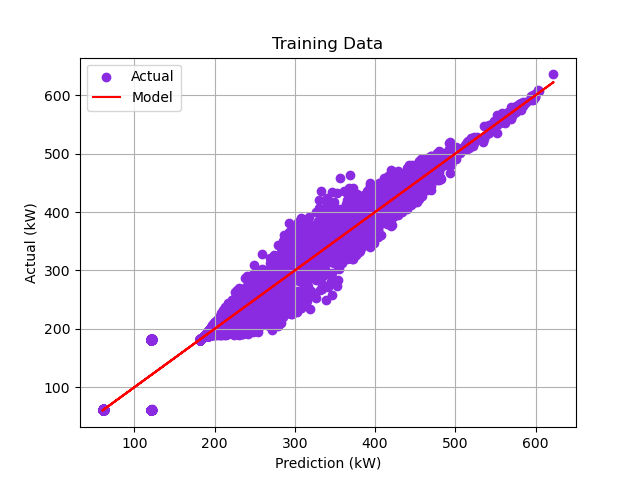

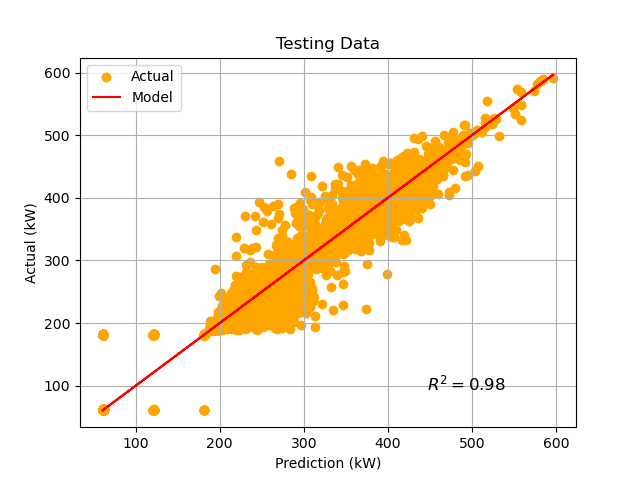

In [4]:
# kNN metrics, plot data vs predictions (training and testing)

#check top performing n_neighbors value
print(knn_gscv.best_params_)

#check mean score for the top performing value of n_neighbors
print(knn_gscv.best_score_)

fig, ax = plt.subplots()
ax.scatter(y3_predict_train,y3_train, c='blueviolet', label='Actual')
ax.plot(y3_predict_train, y3_predict_train, c="red", label='Model')
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Training Data')
ax.legend()
ax.grid()

fig,ax = plt.subplots()
ax.scatter(y3_predict_test, y3_test, c='orange', label='Actual')
ax.plot(y3_predict_test, y3_predict_test, c="red", label='Model')
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Testing Data')
r_squared = sklearn.metrics.r2_score(y3_test, y3_predict_test)
ax.annotate(f'$R^2 = {r_squared:.2f}$', xy=(0.7, 0.1), xycoords='axes fraction', fontsize=12)
ax.legend()
ax.grid()

In [5]:
# Error Evaluation 
# Training error 

print("Train Data")
print("R^2:", r2_score(y3_train, y3_predict_train))
print("MSE:", mean_squared_error(y3_train, y3_predict_train))
print("Root MSE:", np.sqrt(mean_squared_error(y3_train, y3_predict_train)))
print("MAE:", mean_absolute_error(y3_train, y3_predict_train))
print("MAPE: %", mean_absolute_percentage_error(y3_train ,y3_predict_train))

print(" ")

# Test Error
print("Test Data")
print("R^2:", r2_score(y3_test, y3_predict_test))
print("MSE:", mean_squared_error(y3_test, y3_predict_test))
print("Root MSE:", np.sqrt(mean_squared_error(y3_test, y3_predict_test)))
print("MAE:", mean_absolute_error(y3_test, y3_predict_test))
print("MAPE: %", mean_absolute_percentage_error(y3_test, y3_predict_test))

Train Data
R^2: 0.994728379852685
MSE: 67.86839948098705
Root MSE: 8.238227933298948
MAE: 2.6633721629783573
MAPE: % 0.012004110929351221
 
Test Data
R^2: 0.9807140590169606
MSE: 250.3346157121862
Root MSE: 15.821966240394593
MAE: 5.529360068808042
MAPE: % 0.026499894807142016
